# PRBCD RQ1 experiments.

This notebook investigates PR-BCDs behaviour with respect to block size and resampling epochs. And investigates how and when different kinds of edges are useful to the PR-BCDs attack trajectory and final perturbation set.

Phases:
1. Train shared victim model for different seeds.
2. Run small and large block size PR-BCD attacks to extract which edges are seen by each run.
3. Construct four groups of potentially useful and random edges.
4. Probe PR-BCD with edges from these four groups and investigate how they'd influence the PR-BCD loss at different checkpoints.
5. Inject edges from the four groups directly into PR-BCD at different checkpoints to investigate whether they influence the final PR-BCD attack loss.

In [1]:
# Setup: Import libraries and define directories.

from pathlib import Path
import os
import sys
import numpy as np
from IPython.display import display
import gc
import torch
import pandas as pd
from experiments import experiment_global_attack_direct
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"E:\Masterarbeit\AttackerGNN")
DATA_DIR = PROJECT_ROOT / "data"
CACHE_DIR = PROJECT_ROOT / "cache"

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments import experiment_train
from sparse_smoothing.utils import load_and_standardize

print("Project root:", PROJECT_ROOT)

Use from seml.experiment import setup_logger instead.
Note that seml.experiment.Experiment already includes the logger setup.
See https://github.com/TUM-DAML/seml/blob/master/examples/example_experiment.py


Project root: E:\Masterarbeit\AttackerGNN


## Dataset and victim-model generation

These cells define and train the victim models. All experiments in this thesis attack the same victim model. The victim model trains on Cora-ML
The victim model is a 2-Layer GCN with PPR diffusion preprocessing.


In [2]:
DATASET = "cora_ml"
SEEDS = [0]

MODEL_NAME = "GCN"
MODEL_LABEL = "GCN"
MODEL_STORAGE_TYPE = "demo_custom_split"

DROPOUT_VICTIM = 0.5
LR_VICTIM = 1e-2
WEIGHT_DECAY_VICTIM = 1e-3
PATIENCE_VICTIM = 300
MAX_EPOCHS_VICTIM = 3000

# experiment_train uses the repository cache. Existing compatible
# victim models may be reused by the underlying storage layer.
VICTIM_DEVICE = "cpu"
VICTIM_DATA_DEVICE = "cpu"

DATASET_PATH = DATA_DIR / f"{DATASET}.npz"

RQ1_DIR = PROJECT_ROOT / "extendedPlotting" / "final_runs" / "RQ1"
RQ1_DIR.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset file not found: {DATASET_PATH}. "
        "Place the dataset in the repository data folder."
    )

CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Configured dataset={DATASET}, seeds={SEEDS}, model={MODEL_LABEL}")


Configured dataset=cora_ml, seeds=[0], model=GCN


In [4]:
# Train the victim model
for seed in SEEDS:

    print(f"Training or loading victim model for seed={seed}")

    stats = experiment_train.run(
        data_dir=str(DATA_DIR),
        dataset=DATASET,
        model_params=dict(
            label=MODEL_LABEL,
            model=MODEL_NAME,
            do_cache_adj_prep=True,
            n_filters=64,
            dropout=DROPOUT_VICTIM,
            svd_params=None,
            jaccard_params=None,
            gdc_params={"alpha": 0.15, "k": 64},
        ),
        train_params=dict(
            lr=LR_VICTIM,
            weight_decay=WEIGHT_DECAY_VICTIM,
            patience=PATIENCE_VICTIM,
            max_epochs=MAX_EPOCHS_VICTIM,
        ),
        binary_attr=False,
        make_undirected=True,
        seed=int(seed),
        artifact_dir=str(CACHE_DIR),
        model_storage_type=MODEL_STORAGE_TYPE,
        ppr_cache_params=dict(),
        device=VICTIM_DEVICE,
        data_device=VICTIM_DATA_DEVICE,
        display_steps=100,
        debug_level="info",
        custom_split_ratios=None,
    )

    print(
        f"seed={seed} | "
        f"clean accuracy={float(stats['accuracy']):.4f}"
    )

Training or loading victim model for seed=0


[08/17/26 20:42:18] INFO     {'dataset': 'cora_ml', 'model_params': {'label': 'GCN',        ]8;id=271493;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=536110;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#180\180]8;;\
                             'model': 'GCN', 'do_cache_adj_prep': True, 'n_filters': 64,                           
                             'dropout': 0.5, 'svd_params': None, 'jaccard_params': None,                           
                             'gdc_params': {'alpha': 0.15, 'k': 64}}, 'train_params':                              
                             {'lr': 0.01, 'weight_decay': 0.001, 'patience': 300,                                  
                             'max_epochs': 3000}, 'binary_attr': False, 'make_undirected':                         
                             True, 'seed': 0, 'artifact_dir':                                                      
                             'E:\\Masterarbeit\\AttackerGNN\\cache', 'model_storage_type':                         
                             'demo_custom_split', 'ppr_cache_params': {}, 'device': 'cpu',                         
                             'display_steps': 100, 'data_device': 'cpu'}                                           

                    INFO     Training set size: 140                                         ]8;id=318046;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=499748;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#216\216]8;;\

                    INFO     Validation set size: 140                                       ]8;id=529202;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=146039;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#217\217]8;;\

                    INFO     Test set size: 2530                                            ]8;id=838234;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=262674;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#218\218]8;;\

...

[08/17/26 20:42:35] INFO     Test accuracy is 0.8351778388023376 with seed 0                ]8;id=842368;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py\experiment_train.py]8;;\:]8;id=149416;file://E:\Masterarbeit\AttackerGNN\experiments\experiment_train.py#271\271]8;;\

                    INFO     Lock 2389956028048 acquired on                                         ]8;id=917595;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=532614;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#274\274]8;;\
                             E:\Masterarbeit\AttackerGNN\cache\demo_custom_split.json.lock                         

                    INFO     Lock 2389956028048 released on                                         ]8;id=305230;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py\filelock.py]8;;\:]8;id=740883;file://E:\Anaconda\envs\Masterarbeit\Lib\site-packages\filelock.py#318\318]8;;\
                             E:\Masterarbeit\AttackerGNN\cache\demo_custom_split.json.lock                         

,n_seeds,clean_accuracy_mean,clean_accuracy_std,clean_accuracy_count,clean_accuracy_sem,n_train_epochs_mean,n_train_epochs_std,n_train_epochs_count,n_train_epochs_sem,n_val_epochs_mean,n_val_epochs_std,n_val_epochs_count,n_val_epochs_sem
0,1,0.835178,0.0,1,0.0,666.0,0.0,1,0.0,666.0,0.0,1,0.0


Generated SEED_CONTEXTS for: [0]
Victim cache: E:\Masterarbeit\AttackerGNN\cache
Graph nodes: 2810
Undirected edges: 7981


## Experimental configuration

Defines:
1. The used small and large block sizes used by PR-BCD as injection and probe targets and reference for group construction respectively.
2. Shared PR-BCD budget fraction, epochs and finetuning epochs.
3. Shared probe and injection checkpoints.
4. Four probe and injection groups.
5. Number of edges used to fill these four groups.
6. Shared sampling seed.

In [5]:
# ============================================================
# Experiment configuration
# ============================================================

MISS_EPSILON = 0.015

SMALL_BLOCK_SIZES = [250, 500, 1_000, 2_000, 3_000, 4_000]
LARGE_BLOCK_SIZE = 50_000

EPOCHS = 300
FINE_TUNE_EPOCHS = 250
WITH_EARLY_STOPPING = False

GROUPS = ["large_final_missed", "large_top_weight", "large_only_random", "random_unseen_control"]
GROUP_LABELS = {
    "large_final_missed": "large final missed",
    "large_top_weight": "large top weight",
    "large_only_random": "large only random",
    "random_unseen_control": "unseen control",
}

CHECKPOINTS = [0, 24, 49, 99, 299]

N_TOP_WEIGHT = 100
N_RANDOM_LARGE_ONLY = 100
N_RANDOM_UNSEEN = 100

N_INJECTION_EDGES = 10

SAMPLING_SEEDS = {seed: 730_000 + seed * 10_000 for seed in SEEDS}

ARTIFACT_DIR = str(PROJECT_ROOT / "cache")
PERT_ADJ_STORAGE_TYPE = "evasion_global_adj"
PERT_ATTR_STORAGE_TYPE = "evasion_global_attr"

'MISS_EPSILON = 0.01\n# Increase this only when every configured block remains larger than the resulting attack budget.\n\nSMALL_BLOCK_SIZES = [250,500,1_000,2000,3000,4000]\nLARGE_BLOCK_SIZE = 50_000\n\nEPOCHS = 300\nFINE_TUNE_EPOCHS = 250\nN_RESAMPLING_EPOCHS = EPOCHS - FINE_TUNE_EPOCHS\nWITH_EARLY_STOPPING = False\n\nREPEATS_PER_SEED = 1\n\n# Checkpoints are evaluated after the update/projection of the corresponding\n# epoch and before resampling.\nCHECKPOINT_EPOCHS = sorted({\n    epoch\n    for epoch in [0, 9, 24, N_RESAMPLING_EPOCHS - 1, 99, EPOCHS - 1]\n    if 0 <= epoch < EPOCHS\n})\n\n# Candidate construction for the counterfactual probe replay.\nN_TOP_SIGNAL_LARGE_ONLY = 100\nN_RANDOM_LARGE_ONLY = 100\nN_RANDOM_UNSEEN_CONTROLS = 100\nMAX_LARGE_FINAL_MISSED = 100\nMAX_TOTAL_PROBES = 400\n\n# A positive delta means that the one-edge-replaced block has a larger\n# post-step PRBCD attack loss than the unchanged block after the same step.\nPOSITIVE_DELTA_TOL = 1e-7\nROBUST_POSITIV

In [6]:
graph_sparse = load_and_standardize(
    str(DATA_DIR / f"{DATASET}.npz")
)

N_NODES = int(graph_sparse.adj_matrix.shape[0])
N_UNDIRECTED = int(graph_sparse.adj_matrix.nnz() // 2)
N_POSSIBLE_EDGES = N_NODES * (N_NODES - 1) // 2

ATTACK_BUDGET = max(1, round(MISS_EPSILON * N_UNDIRECTED))
ALL_BLOCK_SIZES = sorted(set(SMALL_BLOCK_SIZES + [LARGE_BLOCK_SIZE]))

# Check from PR-BCD. PR-BCD cant run when block size is smaller than requested number of perturbations.
invalid_block_sizes = [
    block_size
    for block_size in ALL_BLOCK_SIZES
    if block_size <= ATTACK_BUDGET
]

if invalid_block_sizes:
    raise ValueError(
        f"All block sizes must exceed "
        f"attack budget={ATTACK_BUDGET}. "
        f"Invalid block sizes: {invalid_block_sizes}."
    )

print("Graph nodes:", N_NODES)
print("Undirected edges:", N_UNDIRECTED)
print("Possible edge flips:", f"{N_POSSIBLE_EDGES:,}")
print("Attack budget:", ATTACK_BUDGET)

Possible edge flips: 3,946,645
Attack budget: 120


'# Verify that the patched PRBCD class is loaded.\nrequired_args = {\n    "miss_diagnostics_enabled",\n    "miss_sampling_seed",\n    "miss_checkpoint_epochs",\n    "miss_probe_linear_ids",\n    "miss_injection_linear_ids",\n    "miss_retention_policy",\n}\nmissing_args = required_args - set(inspect.signature(PRBCD.__init__).parameters)\nif missing_args:\n    raise RuntimeError(\n        "The local PRBCD diagnostics overlay is not active. Missing "\n        f"constructor arguments: {sorted(missing_args)}. Run the import/"\n        "activation cell again."\n    )\n\nif not SEED_CONTEXTS:\n    raise RuntimeError("Victim-data generation produced no SEED_CONTEXTS.")\n\nN_NODES = int(SEED_CONTEXTS[0]["n_nodes"])\nN_UNDIRECTED = int(SEED_CONTEXTS[0]["n_undirected"])\nN_POSSIBLE_EDGES = N_NODES * (N_NODES - 1) // 2\nATTACK_BUDGET = max(1, round(MISS_EPSILON * N_UNDIRECTED))\n\nALL_BLOCK_SIZES = sorted(set(SMALL_BLOCK_SIZES + [LARGE_BLOCK_SIZE]))\nif any(block_size <= ATTACK_BUDGET for block_s

## Phase 1 — paired discovery runs

These cells run PR-BCD attacks for all previously defined block sizes and uses the large block size run as reference.

In [ ]:

def get_ever_seen_edges(result):
    epoch_blocks = result["attack_statistics"]["block_diagnostics"]["epoch_blocks"]
    return torch.unique(torch.cat([torch.as_tensor(block).cpu().long()for block in epoch_blocks.values()]),sorted=True)

# Run PR-BCD with block diagnostics
def run_prbcd(victim_seed, block_size, sampling_seed):

    attack_params = {
        "block_size": block_size,
        "epochs": EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "with_early_stopping": WITH_EARLY_STOPPING,
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",
        "block_diagnostics_enabled": True,
        "attack_sampling_seed": sampling_seed,
    }

    return experiment_global_attack_direct.run(
        graph=graph_sparse,
        data_dir=str(PROJECT_ROOT / "data"),
        dataset=DATASET,
        attack="PRBCD",
        attack_params=attack_params,
        selector_params={},
        epsilons=[MISS_EPSILON],
        binary_attr=False,
        make_undirected=True,
        seed=int(victim_seed),
        artifact_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
        model_label=MODEL_LABEL,
        model_storage_type=MODEL_STORAGE_TYPE,
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=True,
        use_cert="none",
    )


# ------------------------------------------------------------
# Paired discovery runs
# ------------------------------------------------------------

discovery_runs = []
for victim_seed in SEEDS:

    for block_size in ALL_BLOCK_SIZES:
        result = run_prbcd(
            victim_seed=victim_seed,
            block_size=block_size,
            sampling_seed=SAMPLING_SEEDS[victim_seed],
        )
        diagnostics = (result["attack_statistics"]["block_diagnostics"])
        ever_seen = get_ever_seen_edges(result)
        max_weight = diagnostics["max_weight"][ever_seen].cpu().float()
        final_edges = torch.as_tensor(diagnostics["final_linear_ids"]).cpu().long()
        final_accuracy = torch.as_tensor(result["results"][0]["accuracy"]).item()
        discovery_runs.append({
            "seed": victim_seed,
            "sampling_seed": SAMPLING_SEEDS[victim_seed],
            "block_size": block_size,
            "ever_seen": ever_seen,
            "max_weight": max_weight,
            "final_edges": final_edges,
            "final_accuracy": final_accuracy,
        })

        del result
        gc.collect()

# Small overview table
discovery_df = pd.DataFrame([
    {
        "seed": run["seed"],
        "sampling_seed": run["sampling_seed"],
        "block_size": run["block_size"],
        "n_ever_seen": run["ever_seen"].numel(),
        "n_final_edges": run["final_edges"].numel(),
        "final_accuracy": run["final_accuracy"],
    }
    for run in discovery_runs
])

display(discovery_df)

## Phase 2 — candidate construction and counterfactual probe replays

For each paired small/large run, candidate groups are built without calling
them harmful:

- `large_final_missed`: selected by the large run and never seen by the small.
- `large_top_signal`: large-only edges with the largest learned weights and
  positive-gradient accumulation.
- `large_only_random`: random edges seen only by the large run.
- `random_unseen_control`: uniform edges seen by neither paired run.

The small run is then replayed with the same seed. At fixed checkpoints each
candidate receives exact discrete and relaxed marginal-loss measurements plus
its gradient at epsilon.

In [8]:
# ============================================================
# Phase 2: construct four groups
# ============================================================

candidate_rows = []

for victim_seed in SEEDS:

    large_run = next(run for run in discovery_runs
        if run["seed"] == victim_seed
        and run["block_size"] == LARGE_BLOCK_SIZE
    )

    large_seen = large_run["ever_seen"]
    large_final = large_run["final_edges"]
    large_max_weight = large_run["max_weight"]

    for small_block_size in SMALL_BLOCK_SIZES:

        small_run = next(run for run in discovery_runs
            if run["seed"] == victim_seed
            and run["block_size"] == small_block_size
        )
        small_seen = small_run["ever_seen"]

        # Edges seen by large but not by small
        large_only_mask = ~torch.isin(large_seen,small_seen)
        large_only_edges = large_seen[large_only_mask]
        large_only_weights = large_max_weight[large_only_mask]

        # Group 1: large_final_missed
        large_final_missed = large_final[~torch.isin(large_final, small_seen)]

        # Group 2: large_top_signal
        n_top = min(N_TOP_WEIGHT,large_only_edges.numel())
        top_indices = torch.topk(large_only_weights,k=n_top).indices
        large_top_weight = large_only_edges[top_indices]

        # Group 3: large_only_random
        rng = np.random.default_rng(900_000 + victim_seed * 10_000 + small_block_size)
        n_random = min(N_RANDOM_LARGE_ONLY, large_only_edges.numel())
        random_indices = rng.choice(
            large_only_edges.numel(),
            size=n_random,
            replace=False,
        )
        large_only_random = large_only_edges[torch.as_tensor(random_indices)]

        # Group 4: random edges unseen by both runs
        all_edges = torch.arange(N_POSSIBLE_EDGES)
        seen_by_either = torch.unique(torch.cat([small_seen, large_seen]))
        unseen_edges = all_edges[~torch.isin(all_edges, seen_by_either)]
        random_indices = torch.randperm(unseen_edges.numel())[:N_RANDOM_UNSEEN]
        random_unseen = unseen_edges[random_indices]

        groups = {
            "large_final_missed": large_final_missed,
            "large_top_weight": large_top_weight,
            "large_only_random": large_only_random,
            "random_unseen_control": random_unseen,
        }

        for group, edges in groups.items():
            for edge_id in edges.tolist():
                candidate_rows.append({
                    "seed": victim_seed,
                    "small_block_size": small_block_size,
                    "group": group,
                    "linear_id": edge_id,
                })


candidate_df = pd.DataFrame(candidate_rows)

In [ ]:
# ============================================================
# Phase 3: counterfactual loss probe
# ============================================================

# PRBCD epochs are zero-indexed.
# These correspond to after 1, 10, 25, 50, 100 and 300 updates.

def run_probe_prbcd(victim_seed, block_size, sampling_seed, probe_ids, probe_groups):

    attack_params = {
        "block_size": block_size,
        "epochs": EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "with_early_stopping": WITH_EARLY_STOPPING,
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",
        "block_diagnostics_enabled": True,
        "attack_sampling_seed": sampling_seed,
        "probe_ids": probe_ids,
        "probe_groups": probe_groups,
        "probe_checkpoint_epochs": CHECKPOINTS,
    }

    return experiment_global_attack_direct.run(
        graph=graph_sparse,
        data_dir=str(PROJECT_ROOT / "data"),
        dataset=DATASET,
        attack="PRBCD",
        attack_params=attack_params,
        selector_params={},
        epsilons=[MISS_EPSILON],
        binary_attr=False,
        make_undirected=True,
        seed=int(victim_seed),
        artifact_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
        model_label=MODEL_LABEL,
        model_storage_type=MODEL_STORAGE_TYPE,
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=True,
        use_cert="none",
    )

probe_rows = []
for victim_seed in SEEDS:

    for small_block_size in SMALL_BLOCK_SIZES:

        candidates = candidate_df[(candidate_df["seed"] == victim_seed) & (candidate_df["small_block_size"] == small_block_size)]

        probe_ids = candidates["linear_id"].astype(int).tolist()
        probe_groups = candidates["group"].tolist()

        result = run_probe_prbcd(
            victim_seed=victim_seed,
            block_size=small_block_size,
            sampling_seed=SAMPLING_SEEDS[victim_seed],
            probe_ids=probe_ids,
            probe_groups=probe_groups,
        )

        for probe in result["attack_statistics"]["probe_results"]:
            probe_rows.append({
                "seed": victim_seed,
                "small_block_size":small_block_size,
                **probe,
            })

        del result
        gc.collect()


probe_df = pd.DataFrame(probe_rows)
print("Total probes:", len(probe_df))
probe_df.to_csv(RQ1_DIR / "probe_results.csv", index=False)
display(probe_df)

### Aggregate contextual harmfulness

C:\Users\Schulz\AppData\Local\Temp\ipykernel_6644\1930935898.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


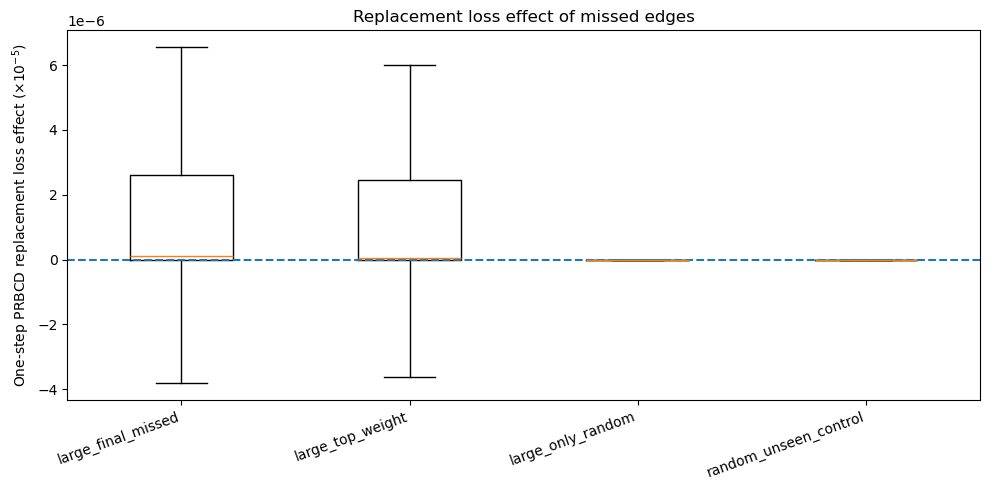

In [16]:
# ============================================================
# Plot: counterfactual usefulness of missed edges
# ============================================================

plot_data = [
    probe_df.loc[
        probe_df["group"] == group,
        "delta_loss",
    ].values
    for group in GROUPS
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    plot_data,
    labels=GROUPS,
    showfliers=False,
)

plt.axhline(0, linestyle="--")

plt.title("Replacement loss effect of missed edges")
plt.ylabel(r"One-step PRBCD replacement loss effect")

plt.xticks(rotation=20, ha="right")

plt.tight_layout()

plt.savefig(
    RQ1_DIR / "boxplot_replacement_loss.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

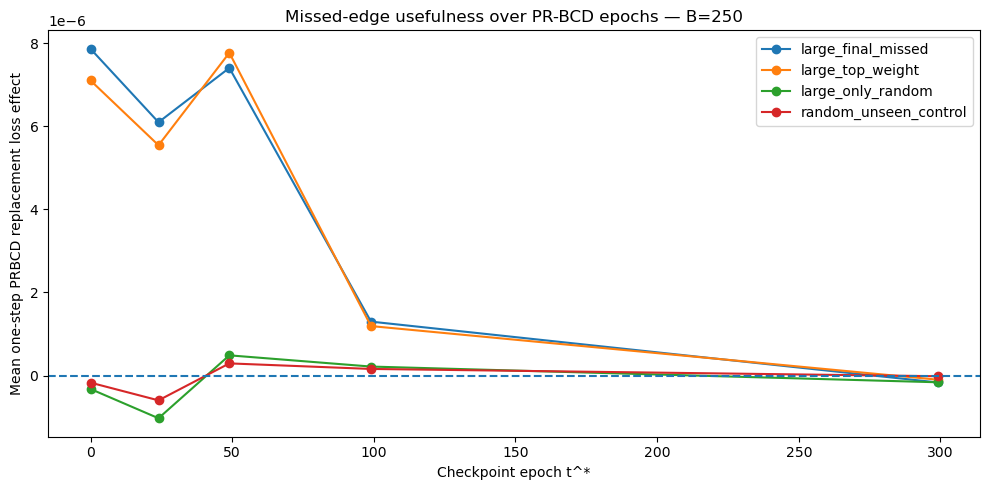

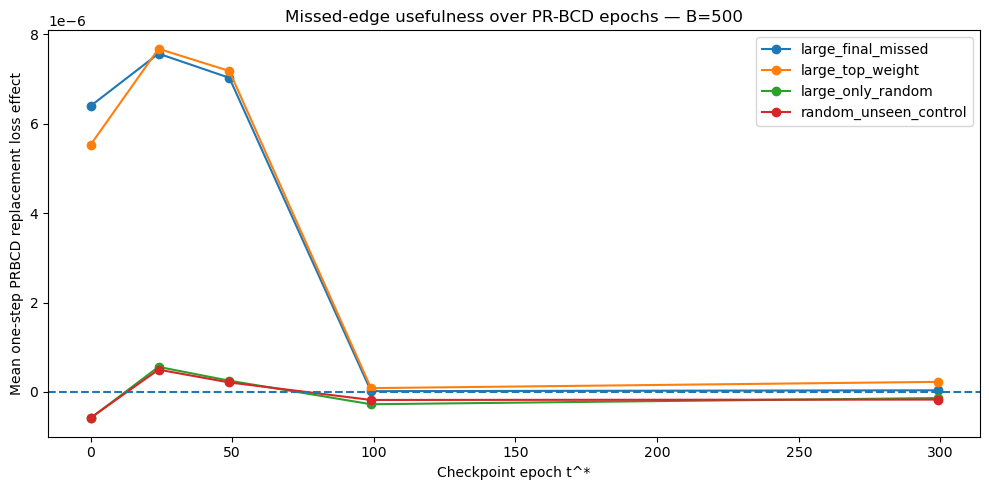

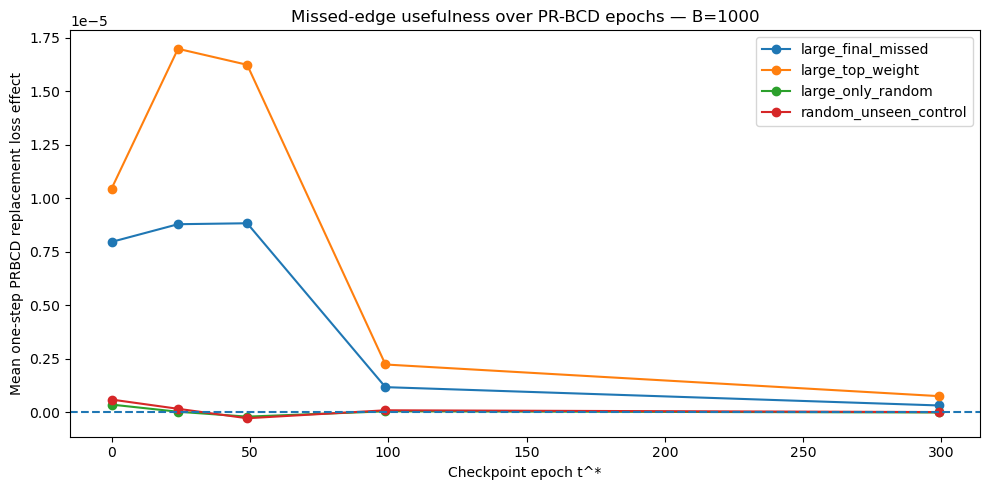

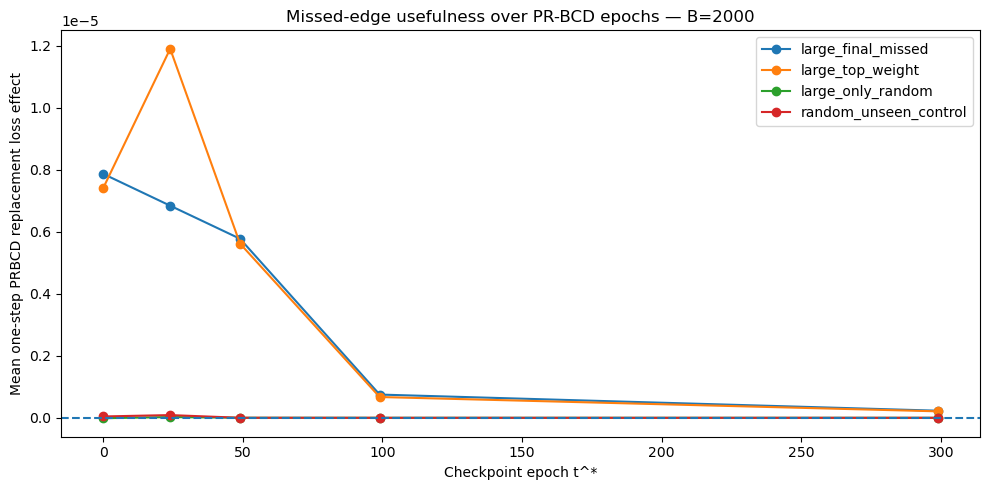

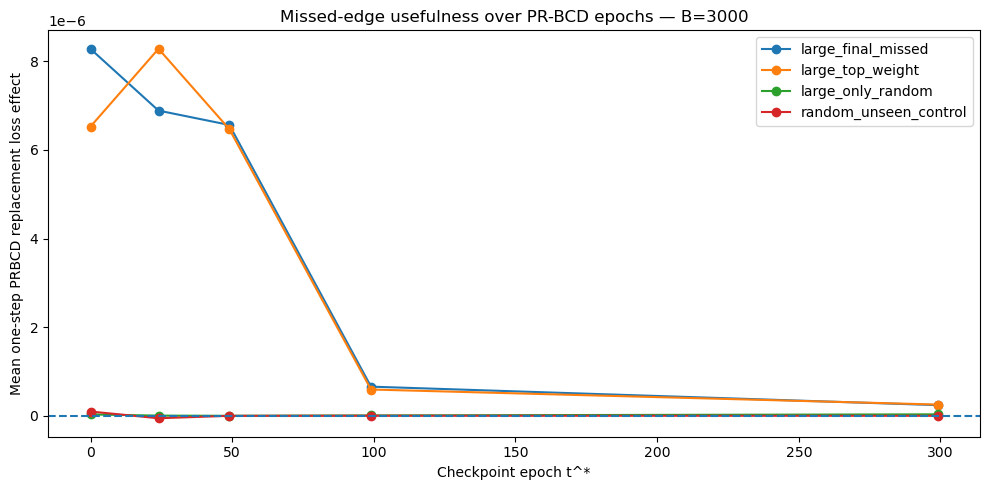

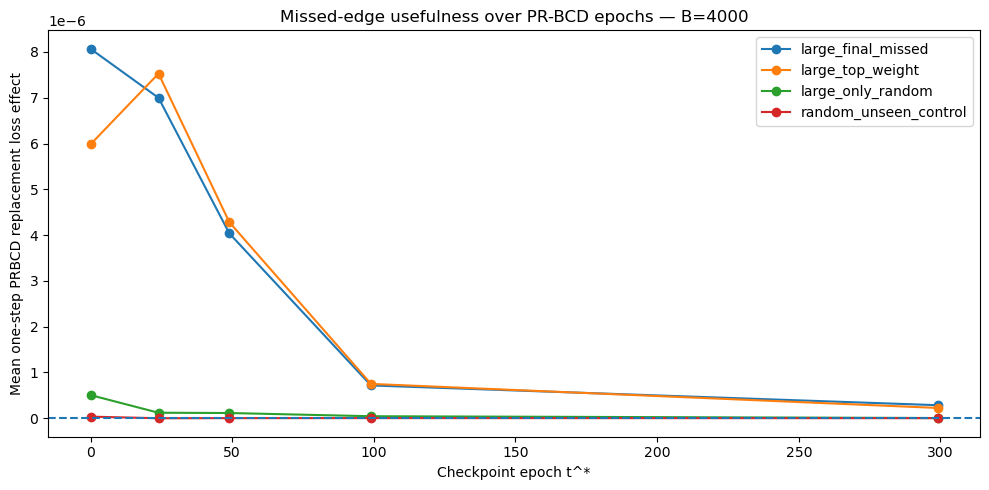

In [21]:
# ============================================================
# Plot: missed-edge usefulness over time for all block sizes
# ============================================================

# Mean over all seeds and all candidate edges within each group
time_df = (probe_df.groupby([
            "small_block_size",
            "checkpoint_epoch",
            "group"],
        as_index=False,
    )["delta_loss"].mean())

for block_size in SMALL_BLOCK_SIZES:
    block_df = time_df[time_df["small_block_size"] == block_size]
    plt.figure(figsize=(10, 5))
    for group in GROUPS:
        group_df = block_df[block_df["group"] == group]
        plt.plot(
            group_df["checkpoint_epoch"],
            group_df["delta_loss"],
            marker="o",
            label=group,
        )

    plt.axhline(0, linestyle="--")

    plt.title(
        f"Missed-edge usefulness over PR-BCD epochs — B={block_size}"
    )

    plt.xlabel(r"Checkpoint epoch $t^*$")
    plt.ylabel("Mean one-step PRBCD replacement loss effect")

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        RQ1_DIR / f"replacement_loss_checkpoint_B{block_size}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

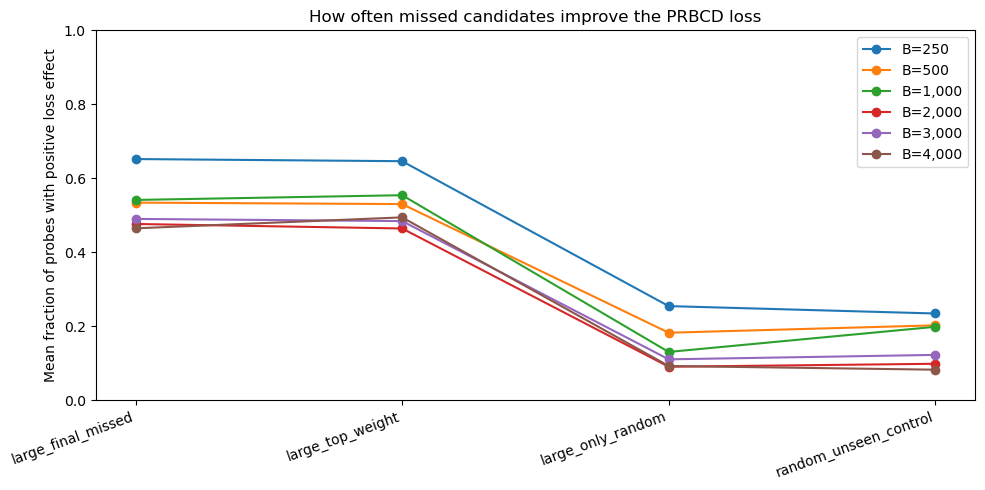

In [22]:
# ============================================================
# Plot: fraction of probes with positive loss effect
# ============================================================

positive_df = probe_df.copy()
positive_df["positive_effect"] = positive_df["delta_loss"] > 0

# Fraction positive within each seed/checkpoint/group
positive_by_checkpoint = (positive_df.groupby([
            "seed",
            "small_block_size",
            "checkpoint_epoch",
            "group"], as_index=False,
    )["positive_effect"].mean()
)

# Average those fractions over seeds and checkpoints
positive_summary = (positive_by_checkpoint
    .groupby([
            "small_block_size",
            "group"], as_index=False)["positive_effect"]
    .mean())

plt.figure(figsize=(10, 5))
for block_size in SMALL_BLOCK_SIZES:
    block_df = positive_summary[positive_summary["small_block_size"] == block_size]
    values = [block_df.loc[block_df["group"] == group, "positive_effect"].iloc[0]
        for group in GROUPS
    ]

    plt.plot(GROUPS, values, marker="o", label=f"B={block_size:,}",)

plt.title("How often missed candidates improve the PRBCD loss")
plt.ylabel("Mean fraction of probes with positive loss effect")

plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    RQ1_DIR / "replacement_loss_positive.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Phase 3 — causal injection

For each small run, select the strongest robustly harmful large-only edges.
Inject them at the checkpoint where their average measured effect was largest.
Compare against the same number of random-unseen control edges injected at the
same epoch. The baseline is the original small discovery run.

In [ ]:
# ============================================================
# Phase 4: causal edge-injection experiment
# ============================================================


def run_injection_prbcd(
    victim_seed,
    block_size,
    sampling_seed,
    injection_ids=None,
    injection_epoch=None,
):

    attack_params = {
        "block_size": block_size,
        "epochs": EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "with_early_stopping": WITH_EARLY_STOPPING,
        "keep_heuristic": "WeightOnly",
        "do_synchronize": True,
        "loss_type": "tanhMargin",
        "attack_sampling_seed": sampling_seed,
        "injection_ids": injection_ids or [],
        "injection_epoch": injection_epoch,
    }

    return experiment_global_attack_direct.run(
        graph=graph_sparse,
        data_dir=str(PROJECT_ROOT / "data"),
        dataset=DATASET,
        attack="PRBCD",
        attack_params=attack_params,
        selector_params={},
        epsilons=[MISS_EPSILON],
        binary_attr=False,
        make_undirected=True,
        seed=int(victim_seed),
        artifact_dir=ARTIFACT_DIR,
        pert_adj_storage_type=PERT_ADJ_STORAGE_TYPE,
        pert_attr_storage_type=PERT_ATTR_STORAGE_TYPE,
        model_label=MODEL_LABEL,
        model_storage_type=MODEL_STORAGE_TYPE,
        device="cpu",
        data_device="cpu",
        debug_level="info",
        semi=True,
        use_cert="none",
    )

injection_rows = []

for victim_seed in SEEDS:
    for small_block_size in SMALL_BLOCK_SIZES:

        baseline_row = discovery_df[
            (discovery_df["seed"] == victim_seed)
            & (discovery_df["block_size"] == small_block_size)
            & (discovery_df["sampling_seed"] == SAMPLING_SEEDS[victim_seed])
        ]

        baseline_final_accuracy = baseline_row.iloc[0]["final_accuracy"]

        # Run PR-BCD with injection
        for injection_epoch in CHECKPOINTS:
            for group in GROUPS:
                candidates = candidate_df[
                    (candidate_df["seed"] == victim_seed)
                    & (
                        candidate_df["small_block_size"]
                        == small_block_size
                    )
                    & (candidate_df["group"] == group)
                ]

                # Deterministic batch of 10 candidates
                all_injection_ids = candidates["linear_id"].tolist()

                # Split all group edges into batches of 10
                batches = [all_injection_ids[i:i + N_INJECTION_EDGES]
                    for i in range(0, len(all_injection_ids),N_INJECTION_EDGES)]

                # Run PR-BCD once with the corresponding batch injected.
                for injection_ids in batches:
                    result = run_injection_prbcd(
                        victim_seed=victim_seed,
                        block_size=small_block_size,
                        sampling_seed=SAMPLING_SEEDS[victim_seed],
                        injection_ids=injection_ids,
                        injection_epoch=injection_epoch,
                    )

                    injection_final_accuracy = float(result["results"][0]["accuracy"])

                    injection_rows.append({
                        "seed": victim_seed,
                        "small_block_size": small_block_size,
                        "injection_epoch": injection_epoch,
                        "injection_update": injection_epoch + 1,
                        "group": group,
                        "n_injected": len(injection_ids),
                        "baseline_final_accuracy": baseline_final_accuracy,
                        "injection_final_accuracy":injection_final_accuracy,
                        "final_accuracy_delta": baseline_final_accuracy - injection_final_accuracy,
                    })

                    del result
                    gc.collect()

injection_df = pd.DataFrame(injection_rows)

### Injection plots

In [ ]:
# ============================================================
# Plot: injection effect of the four candidate groups
# ============================================================

for block_size in SMALL_BLOCK_SIZES:

    block_df = injection_df[injection_df["small_block_size"] == block_size]

    box_data = []
    box_positions = []
    box_labels = []

    position = 1

    for injection_epoch in CHECKPOINTS:
        for group in GROUPS:
            values = 100*block_df.loc[
                (block_df["injection_epoch"] == injection_epoch)
                & (block_df["group"] == group),
                "final_accuracy_delta",
            ].dropna().values

            box_data.append(values)
            box_positions.append(position)

            box_labels.append(f"{injection_epoch}\n{GROUP_LABELS[group]}")
            position += 1

        # gap between checkpoints
        position += 0.7

    plt.figure(figsize=(16, 5.5))
    plt.boxplot(
        box_data,
        positions=box_positions,
        labels=box_labels,
        showfliers=False,
        widths=0.65,
    )

    # Show individual seed results as points
    for pos, values in zip(box_positions, box_data):
        plt.scatter(
            np.full(len(values), pos),
            values,
            s=22,
            zorder=3,
        )

    plt.axhline(0, linestyle="--")
    plt.title(
        f"Injection effect in final PR-BCD accuracy of the four original candidate groups — "
        f"B={block_size:,}"
    )

    plt.xlabel("Injection epoch and original injection group")
    plt.ylabel("Final accuracy reduction vs. baseline (pp)")
    plt.xticks(rotation=45, ha="right")

    plt.grid(axis="y", alpha=0.25)

    plt.tight_layout()

    plt.savefig(
        RQ1_DIR / f"injection_effect_B{block_size}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()